<a href="https://colab.research.google.com/github/qndks11/cv-playground/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch 다운로드

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 32
EPOCHS = 25

# FashionMNIST 다운로드
FashionMNIST는 10종류의 흑백 옷 이미지 데이터셋이고 크기는 28x28입니다.

In [3]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()])

# 트레이닝 데이터 다운로드
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
# 테스트 데이터 다운로드
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size = BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size = BATCH_SIZE, shuffle=True)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.34MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 145kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.9MB/s]


# CNN 모델

In [4]:
class CNN(torch.nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1)
    self.conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1)
    self.pool = torch.nn.MaxPool2d(kernel_size=2)
    self.relu = torch.nn.ReLU(inplace=True)

    self.fc1 = torch.nn.Linear(32*5*5, 64)
    self.fc2 = torch.nn.Linear(64, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

# 학습

In [6]:
model = CNN().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()

for epoch in range(EPOCHS):
  running_loss = 0.0

  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()              # 그레디언트 초기화
    outputs = model(images)            # Forward
    loss = criterion(outputs, labels)  # loss 계산
    loss.backward()                    # Backward
    optimizer.step()                   # 가중치 업데이트

    running_loss += loss.item()

  avg_loss = running_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Epoch [1/25], Loss: 0.5217
Epoch [2/25], Loss: 0.3472
Epoch [3/25], Loss: 0.3021
Epoch [4/25], Loss: 0.2715
Epoch [5/25], Loss: 0.2499
Epoch [6/25], Loss: 0.2334
Epoch [7/25], Loss: 0.2189
Epoch [8/25], Loss: 0.2060
Epoch [9/25], Loss: 0.1957
Epoch [10/25], Loss: 0.1859
Epoch [11/25], Loss: 0.1742
Epoch [12/25], Loss: 0.1661
Epoch [13/25], Loss: 0.1573
Epoch [14/25], Loss: 0.1499
Epoch [15/25], Loss: 0.1452
Epoch [16/25], Loss: 0.1351
Epoch [17/25], Loss: 0.1277
Epoch [18/25], Loss: 0.1248
Epoch [19/25], Loss: 0.1189
Epoch [20/25], Loss: 0.1129
Epoch [21/25], Loss: 0.1064
Epoch [22/25], Loss: 0.1039
Epoch [23/25], Loss: 0.0979
Epoch [24/25], Loss: 0.0935
Epoch [25/25], Loss: 0.0931


# 평가

In [7]:
model.eval()

correct = 0
total = 0

# 틀린 예측 모으기
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item() # 맞춘 개수가 나옴
    mask = predicted != labels
    wrong_images.extend(images[mask].cpu())
    wrong_preds.extend(predicted[mask].cpu())
    wrong_labels.extend(labels[mask].cpu())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 90.69%


## 틀린 예측

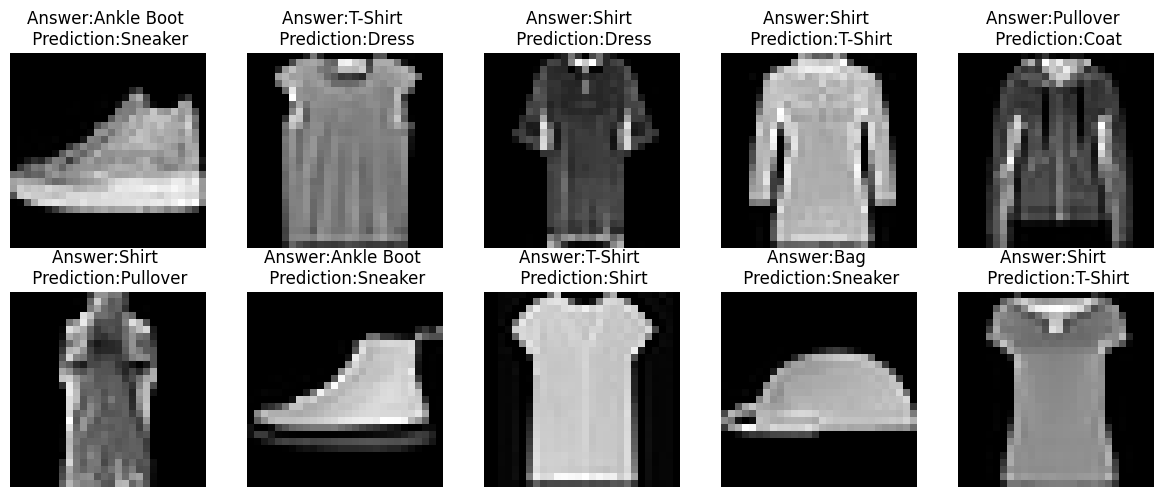

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

for i, ax in enumerate(axes.flat):
    if i >= len(wrong_images):
        break
    img = wrong_images[i].squeeze()  # (1,28,28) -> (28,28)
    ax.imshow(img, cmap='gray') # imshow는 기본적으로 컬러맵을 적용
    ax.set_title(f"Answer:{labels_map[wrong_labels[i].item()]} \n Prediction:{labels_map[wrong_preds[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()